# OceanDataCatalog | NOC Near-Present Day

## About

This Notebook demonstrates how to use the **OceanDataCatalog** API to explore the [Near-Present-Day](https://noc-msm.github.io/NOC_Near_Present_Day/) global ocean sea-ice simulations developed by the National Oceanography Centre as part of the Atlantic Climate and Environment Strategic Science ([AtlantiS](https://noc.ac.uk/projects/atlantis)) programme.

In [1]:
from OceanDataStore import OceanDataCatalog

* Create an instance of the **OceanDataCatalog** class to access the National Oceanography Centre ocean model Spatio-Temporal Access Catalog (`noc-model-stac`):

In [2]:
catalog = OceanDataCatalog(catalog_name="noc-stac")

* Let's use the `available_collections` property to return the names (**IDs**) of all available dataset collections in the `noc-model-stac`:

In [3]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

* Let's use the `.search()` method to search the Near-Present Day ERA-5 collection for all ocean model outputs including the sea surface temperature (SST) standard variable name:

In [4]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y
              Title: T1y Icechunk repository
              Description: **Annual mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m
              Title: T1m Icechunk repository
              Description: **Monthly mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T1y_3d
       

* Now that we have performed a `search` operation on our catalog, we can also use the `available_items` property to return the names (**IDs**) of the available STAC Items resulting from our search.

In [5]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/r1i1c1f1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/r1i1c1f1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca12-era5v1/r1i1c1f1/gn/T5d_3d']

* Now, let's take a closer look at the first Item in our search results. This corresponds to the annual-mean T-grid variables output by the 1-degree NPD eORCA1 ERA5v1 simulation.

* By looking in `properties/variable_standard_names`, we can see that 'sea_surface_temperature' is the 59th variable in this dataset and is named `tos_con`.

In [6]:
catalog.Items[0]

<Item id=noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y>

* Next, let's open a subset (1980-1990) of the annual-mean SST data as an `xarray.Dataset` by using the `.open_dataset()` method and specifying start and end date strings. 

* Here, we use the `.id` attribute of our first *Item*, but we could have also copied the `id` string from above.

In [7]:
ds = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1980-01',
                          end_datetime='1990-12',
                          )

ds

<xarray.Dataset> Size: 9GB
Dimensions:                (time_counter: 11, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 88B 1980-07-02 ... 1...
    time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    vohflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    ttrd_bbl_li            (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>

* Finally, let's create a plot of the time-mean (1980-1990) SST for the globe:

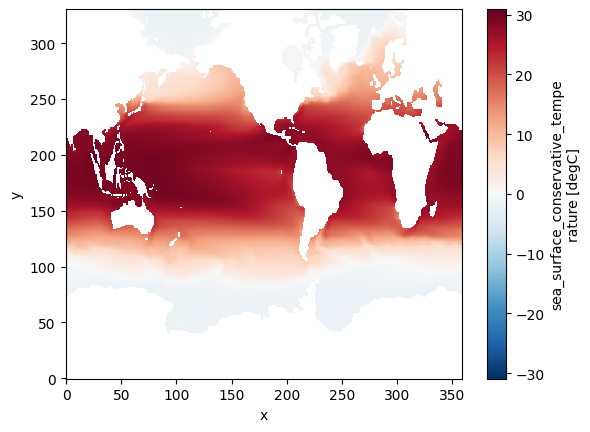

In [8]:
ds['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r')

## Pre-Calculated Diagnostics

* So far, we have seen how to access NPD ocean model variables (e.g., temperature, salinity and velocities) defined on their native NEMO model grid.

* In addition to these variables, we can also access a range of pre-calculated diagnostics, such as the meridional overturning, heat and freshwater transports across the following trans-basin sections:

    - Overturning in the Subpolar North Atlantic Program (**OSNAP**) array
    - Rapid Climate Change-Meridional Overturning Circulation and Heatflux Array (**RAPID-MOCHA**) at 26.5°N
    - Meridional Overturning Variability Experiment (**MOVE**) array at 16°N
    - South Atlantic Meridional overturning circulation Basin-wide Array (**SAMBA**) array at 34.5°S

* These diagnostics are calculated using the [Meridional ovErTurning ciRculation diagnostIC (METRIC)](https://github.com/oj-tooth/metric) package.

* Next, let's see how we can access these diagnostics by searching the `OceanDataCatalog` for any *Items* with identifiers containing the key word **"tn"**, which corresponds to transects which are defined on the native NEMO model grid:


In [9]:
catalog.search(collection='noc-npd-era5', item_name='tn')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/MOVE_16N
              Title: M1m/MOVE_16N Icechunk repository
              Description: **Monthly mean ocean physics transect outputs defined at MOVE_16N.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/MOVE_16N')`
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/SAMBA_34_5S
              Title: M1m/SAMBA_34_5S Icechunk repository
              Description: **Monthly mean global ocean scalar outputs.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/SAMBA_34_5S')`
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c

* We can see from the list of search *Items* that `OSNAP`, `RAPID_26N`, `MOVE_16N` and `SAMBA_34_5S` diagnostics are available for all NPD model configurations.

* Now, let's open the `RAPID_26N` file for the 1-degree NPD eORCA1 ERA5v1 simulation we explored earlier. 

In [10]:
ds_rapid = catalog.open_dataset(id="noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/RAPID_26N")

ds_rapid

<xarray.Dataset> Size: 158MB
Dimensions:        (x: 71, time: 595, z: 75, xbounds: 72)
Coordinates:
  * x              (x) float64 568B -80.5 -79.5 -78.5 ... -12.5 -11.5 -10.5
  * time           (time) datetime64[ns] 5kB 1976-01-16T12:00:00 ... 2025-07-...
  * z              (z) float64 600B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * xbounds        (xbounds) float64 576B -81.0 -80.0 -79.0 ... -11.0 -9.998
Data variables: (12/62)
    dx             (x) float64 568B dask.array<chunksize=(71,), meta=np.ndarray>
    fc             (time) float64 5kB dask.array<chunksize=(298,), meta=np.ndarray>
    dz             (z) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    fw_ek          (time) float64 5kB dask.array<chunksize=(298,), meta=np.ndarray>
    fw_fc          (time) float64 5kB dask.array<chunksize=(298,), meta=np.ndarray>
    ekman          (time) float64 5kB dask.array<chunksize=(298,), meta=np.ndarray>
    ...             ...
    v_basin_model  (time, z) float64 357kB dask.array<chunksize=(1, 75), meta=np.ndarray>
    v_basin_rapid  (time, z) float64 357kB dask.array<chunksize=(1, 75), meta=np.ndarray>
    temp           (time, z, x) float64 25MB dask.array<chunksize=(1, 75, 71), meta=np.ndarray>
    v_fc           (time, z) float64 357kB dask.array<chunksize=(1, 75), meta=np.ndarray>
    wbw            (time) float64 5kB dask.array<chunksize=(298,), meta=np.ndarray>
    vgeo           (time, z, x) float64 25MB dask.array<chunksize=(1, 75, 71), meta=np.ndarray>

## Ocean Model Domain Variables

* So far, we have seen how to access NPD ocean model variables (e.g., temperature, salinity and velocities) defined on their native NEMO model grid.

* But often when calculating diagnostics derived from these variables, such as volume, heat and freshwater transports, we also need access to the variables describing the model domain.

* Let's next search the `OceanDataCatalog` for any *Items* with identifiers which contain the **"domain"** key word:

In [11]:
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/domain/domain_cfg
              Title: domain/domain_cfg Icechunk repository
              Description: **Global ocean model domain and mesh mask variables.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/domain/domain_cfg')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/domain/domain_cfg
              Title: domain/domain_cfg Icechunk repository
              Description: **Global ocean model domain and mesh mask variables.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/domain/domain_cfg')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd

* We can see from the list of search *Items* that `domain_cfg`, `mesh_mask` and `subbasin` ancillary data are available for each NPD model configuration.

* Next, let's open the `domain_cfg` file for the 1-degree NPD eORCA1 ERA5v1 simulation we explored earlier. 

In [12]:
ds_domain_cfg = catalog.open_dataset(id="noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/domain/domain_cfg")

ds_domain_cfg

<xarray.Dataset> Size: 710MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/49)
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e2u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e2f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e2t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    tmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    tmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000